This notebook works through the basic mechanics of creating a portfolio of 50 assets and simulating portfolio growth over time. <br>
We then create a restricted portfolio consisting of a chosen subset of assets and compare its performance to that of the traditional portfolio.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as sk
from sklearn.datasets import make_spd_matrix

In [3]:
# Parameters #

# time
T=1
#increments
n=365

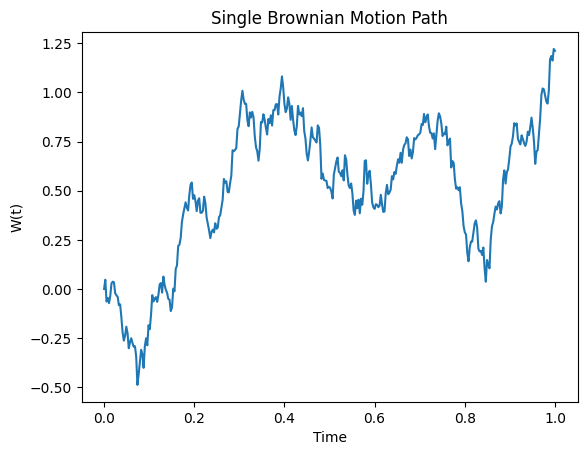

In [4]:
def sim_Brownian(T,n):
    dt=T/n
    Z=np.random.normal(0,1,n)
    dW = np.sqrt(dt) * Z
    W = np.insert(np.cumsum(dW),0,0) 
    # Create mesh
    t=np.linspace (0, T, n+1)
    return t, W

t, W = sim_Brownian(1, 365)
# plot
plt.plot(t, W)
plt.title("Single Brownian Motion Path")
plt.xlabel("Time")
plt.ylabel("W(t)")
plt.show()

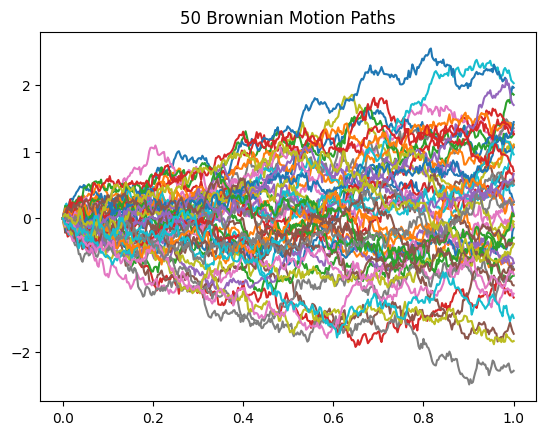

In [5]:
# Rows are different Brownian paths (m paths)
# Columns are time steps (n increments).
# T is time

def sim_mult_Brownian(T,n,m):
    dt=T/n
    Z=np.random.normal(0 , 1 ,(m, n))
    dW = np.sqrt(dt) * Z
    # axis = 1 sums across row. So sum of each path. Allows for mutliple Brownian motions without for loop.
    W = np.cumsum(dW,axis=1)# hstack prepens a zero column to initiate W_{0}=0 for each Brownian motion.
    W = np.hstack([np.zeros((m,1)),W])
    # Create mesh
    t=np.linspace (0, T, n+1)
    return t, W

T=1
n = 365
m = 50

t, W = sim_mult_Brownian(1,365,50)

plt.plot(t,W.T)
plt.title("50 Brownian Motion Paths")
plt.show()

50 geometric brownian motion paths i.e. 50 simulated asset paths

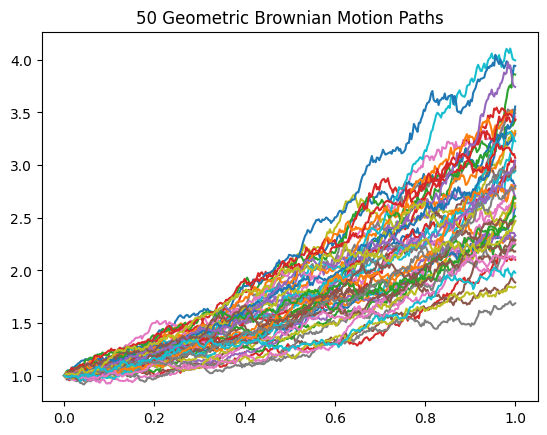

In [6]:
def geo_Brownian(mu,sigma,S0,t,W):
    S_t = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)
    return S_t

mu = 1
sigma = 0.2
S0 = 1
Q = geo_Brownian(mu, sigma, S0, t, W)

plt.plot(t,Q.T)
plt.title("50 Geometric Brownian Motion Paths")
plt.show()

Find Returns of Each Asset

In [7]:
# Q[:,1:] For each asset path, grabs all elements from 1st row onward (s1, s2, ... s365)
# Q[:,:-1] For each asset path, grabs all elements up to last row (s0, s1, s2... s364)
# Element wise division gives the daily returns for each path.
# shape is (50,365) because in this example 50 paths and 365 returns (366 nodes/days but 365 returns between days)

returns = Q[:,1:]/Q[:,:-1] -1
# print(returns)
# print(returns.shape)

Create Portfolio (equal weights of 1/50)

<function matplotlib.pyplot.show(close=None, block=None)>

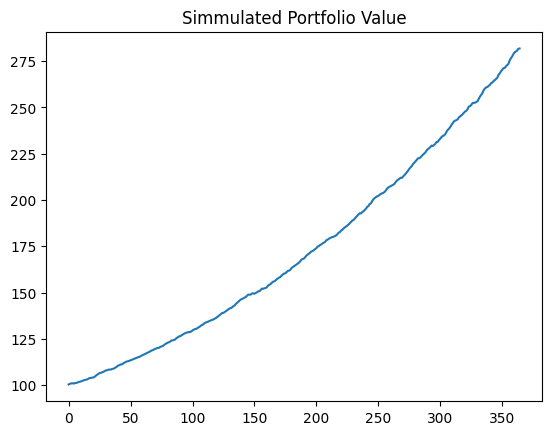

In [8]:
# Create equal weights of 1/m for all m paths
weights = (1/m)*np.ones(m)
# print(weights)
#print(weights.shape)

# Creates daily returns of the portfoilo (dot product of individual daily returns and weights)
def portfolio(w,r):
    P=np.dot(w,r)
    return P

Sim_Port = portfolio(weights,returns)
#print(Sim_Port)
#print(Sim_Port.shape)

P0 = 100

# Accumulates our daily returns (1st column is r1, 2nd is r1*r2, 3rd is r1*r2*r3, etc.)
port_value = P0 * np.cumprod(1+Sim_Port)

plt.plot(port_value)
plt.title("Simmulated Portfolio Value")
plt.show


Restricted Portfolio

<function matplotlib.pyplot.show(close=None, block=None)>

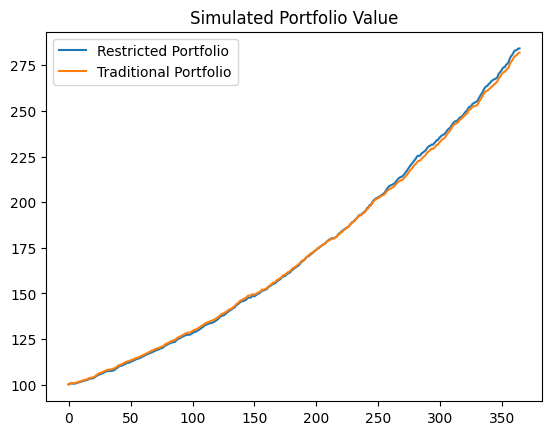

In [9]:
# Say that the company imposes a restriction that assets 41-50 cannot be traded (ex: an ethical restriction)
# Build restricted portfolio to model this case

returns_restricted = returns[:m-10]
weights_restricted = (1/(m-10))*np.ones(m-10)

Sim_PortR = portfolio(weights_restricted, returns_restricted)

P0 = 100

# Accumulates our daily returns (1st column is r1, 2nd is r1*r2, 3rd is r1*r2*r3, etc.)
rest_port_value = P0 * np.cumprod(1+Sim_PortR)

plt.plot(rest_port_value, label = "Restricted Portfolio")
plt.plot(port_value, label = "Traditional Portfolio")
plt.title("Simulated Portfolio Value")
plt.legend()
plt.show


In [10]:
mean_full = np.mean(Sim_Port)
mean_restricted = np.mean(Sim_PortR)
vol_full = np.std(Sim_Port)
vol_restricted = np.std(Sim_PortR)
sharpe_full = mean_full / vol_full
sharpe_restricted = mean_restricted / vol_restricted
total_return_full = port_value[-1]  # final value
total_return_restricted = rest_port_value[-1]



stats_full = {
    'Mean Return': mean_full,
    'Volatility': vol_full,
    'Sharpe': sharpe_full,
    'Total Return': total_return_full
}

stats_restricted = {
    'Mean Return': mean_restricted,
    'Volatility': vol_restricted,
    'Sharpe': sharpe_restricted,
    'Total Return': total_return_restricted
}

# Create the Pandas DataFrame (the table)
# If desired: Transpose the DataFrame (.T) so statistics are rows and columns are the data quantities
stats_table = pd.DataFrame([stats_full,stats_restricted], index=['Traditional Portfolio', 'Restricted Portfolio'])

# Optional enhancements to table to create 
#stats_table['% Diff Mean'] = (stats_restricted['Mean Return'] - stats_full['Mean Return']) / stats_full['Mean Return'] * 100
#stats_table['% Diff Total'] = (stats_restricted['Total Return'] - stats_full['Total Return']) / stats_full['Total Return'] * 100

print(stats_table)

                       Mean Return  Volatility    Sharpe  Total Return
Traditional Portfolio     0.002844    0.001411  2.016375    281.899472
Restricted Portfolio      0.002867    0.001600  1.791729    284.192760


Now let's add correlation between asset movements **Left off here**

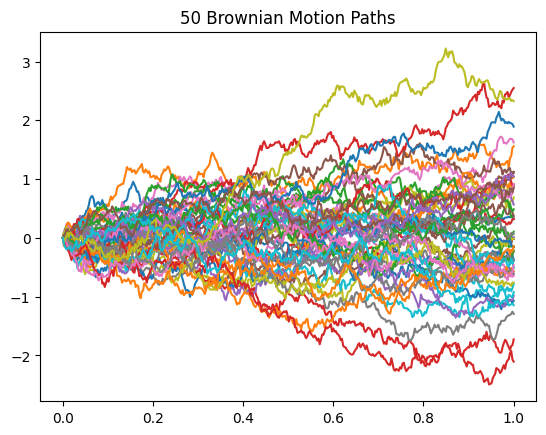

In [11]:
# Rows are different Brownian paths (m paths)
# Columns are time steps (n increments).
# T is time

def sim_mult_corr_Brownian(T,n,m):
    dt=T/n
    Z=np.random.normal(0 , 1 ,(m, n))
   # R=np.random.uniform(0,0.05,size=(m,m))
    #A= np.dot(R,R.T)
    #A_inv = np.diag(1/np.sqrt(np.diag(A)))
    #A= A_inv @ A @ A_inv
    #L=np.linalg.cholesky(A)
    #dW = np.sqrt(dt) * (L@Z)
    dW = np.sqrt(dt)*Z
    # axis = 1 sums across row. So sum of each path. Allows for mutliple Brownian motions without for loop.
    W = np.cumsum(dW,axis=1)# hstack prepens a zero column to initiate W_{0}=0 for each Brownian motion.
    W = np.hstack([np.zeros((m,1)),W])
    # Create mesh
    t=np.linspace (0, T, n+1)
    return t, W

T=1
n = 365
m = 50

t, W = sim_mult_corr_Brownian(1,365,50)

plt.plot(t,W.T)
plt.title("50 Brownian Motion Paths")
plt.show()

In [5]:
X = make_spd_matrix(n_dim=5, random_state = 42)
print(X)

[[ 0.97766615 -0.23316137 -1.21865345 -0.39562     0.92189636]
 [-0.23316137  0.64354244  1.047413    0.38781049 -0.53749089]
 [-1.21865345  1.047413    2.97417899  1.05308457 -1.61639237]
 [-0.39562     0.38781049  1.05308457  0.90057916 -0.78071011]
 [ 0.92189636 -0.53749089 -1.61639237 -0.78071011  1.64198243]]


In [10]:
rho = -.9
C = np.array([[1,rho], [rho, 1]])
print(C)

[[ 1.  -0.9]
 [-0.9  1. ]]


In [11]:
L=np.linalg.cholesky(C)
print(L)

[[ 1.          0.        ]
 [-0.9         0.43588989]]


In [12]:
dt = 1/252

In [14]:
X=np.random.normal(0,dt**(.5),(2,1000))

In [ ]:
CX = np.